<a href="https://colab.research.google.com/github/haroldchukwurah16-blip/ai-image-classifier/blob/main/AI_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [93]:
# Load the Fashion MNIST dataset

fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)

print("Testing images:", test_images.shape)
print("Testing labels:", test_labels.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [94]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

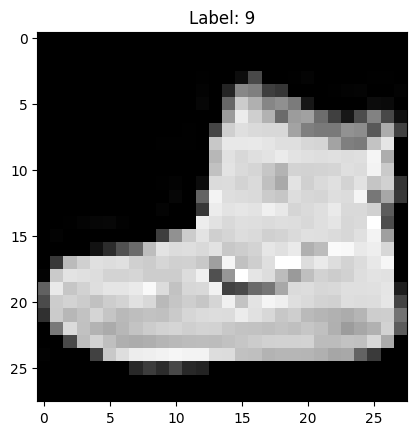

In [95]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0], cmap="gray")
plt.title(f"Label: {train_labels[0]}")
plt.show()

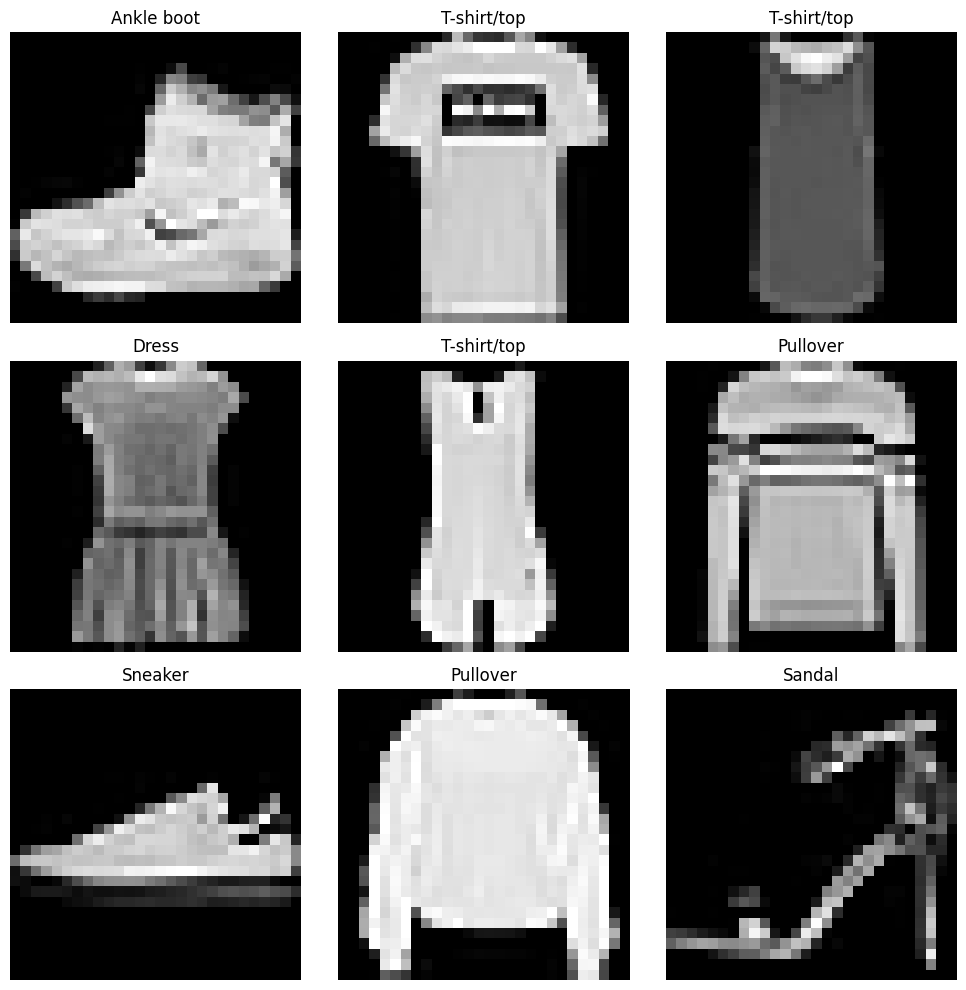

In [96]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(class_names[train_labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [97]:
train_images = train_images / 255.0
test_images = test_images / 255.0

print("Training data range:", train_images.min(), "to", train_images.max())
print("Testing data range:", test_images.min(), "to", test_images.max())

Training data range: 0.0 to 1.0
Testing data range: 0.0 to 1.0


In [98]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully")

Model compiled successfully


In [99]:
history = model.fit(
    train_images,
    train_labels,
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8240 - loss: 0.4985
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8654 - loss: 0.3721
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8781 - loss: 0.3353
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8862 - loss: 0.3111
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8927 - loss: 0.2924
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8976 - loss: 0.2779
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9032 - loss: 0.2648
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9046 - loss: 0.2548
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9085 - loss: 0.2456
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9109 - loss: 0.2373


In [100]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8862 - loss: 0.3375
Test accuracy: 0.8862000107765198
Test loss: 0.3375430405139923


In [101]:
import numpy as np

predictions = model.predict(test_images)

predicted_label = np.argmax(predictions[0])
actual_label = test_labels[0]

print("Predicted:", class_names[predicted_label])
print("Actual:", class_names[actual_label])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: Ankle boot
Actual: Ankle boot


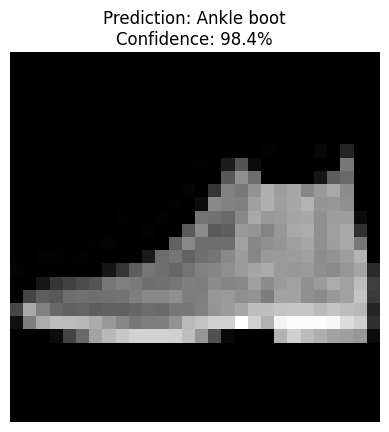

Actual: Ankle boot


In [102]:
confidence = predictions[0][predicted_label] * 100

plt.imshow(test_images[0], cmap="gray")
plt.title(
    f"Prediction: {class_names[predicted_label]}\n"
    f"Confidence: {confidence:.1f}%"
)
plt.axis("off")
plt.show()

print("Actual:", class_names[actual_label])

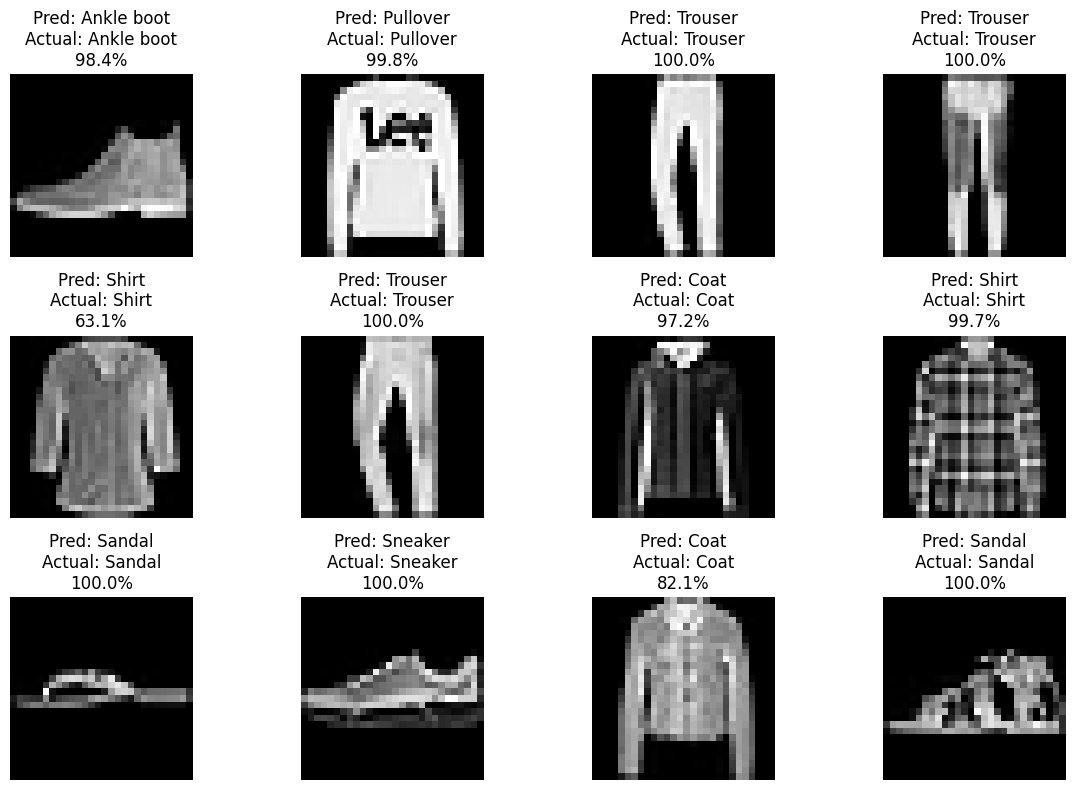

In [103]:
plt.figure(figsize=(12, 8))

for i in range(12):
    predicted_label = np.argmax(predictions[i])
    actual_label = test_labels[i]
    confidence = predictions[i][predicted_label] * 100

    plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[i], cmap="gray")

    plt.title(
        f"Pred: {class_names[predicted_label]}\n"
        f"Actual: {class_names[actual_label]}\n"
        f"{confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [104]:
model.save("fashion_mnist_model.keras")

print("Model saved successfully")

Model saved successfully
